# Odd-One-Out Experiment Pipeline
### CPSY 1950 — Computational Models of Human Behavior

This notebook evaluates LLMs on the **odd-one-out** task from Psych-101 (Binz et al., 2025), based on Hebart et al. (2020)'s THINGS dataset similarity judgments.

In each trial, three words are presented and assigned to keys **D**, **P**, and **H**. The participant (or model) picks the one that is **least similar** to the other two — the "odd one out."

**What this notebook does:**
1. Loads and parses odd-one-out trials from the Psych-101 dataset
2. Queries one or more LLMs via Brown's LiteLLM API at each trial
3. Extracts logprobs for options D, P, and H
4. Computes **NLL** (how surprised is the model by the human's choice?) and **top-1 accuracy**
5. Compares model choice distributions to human choice distributions
6. Visualizes alignment results

**References:**
- Binz et al. (2025). *Centaur: a foundation model of human cognition*
- Hebart et al. (2020). *Revealing the multidimensional mental representations of natural objects underlying human similarity judgements*

---
## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from openai import OpenAI
from dotenv import load_dotenv
from datasets import load_dataset
from tqdm import tqdm
from collections import defaultdict
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

Matplotlib is building the font cache; this may take a moment.


In [4]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

# Confirm available models
models = client.models.list()
for m in models.data:
    print(m.id)

gemini-3-flash-preview
claude-sonnet-4-5
gpt-5.4
Llama-3.3-70B-Instruct
Mistral-Large-3
gpt-5.2


---
## 1. Load Psych-101 Odd-One-Out Data

The odd-one-out experiment in Psych-101 is drawn from **Hebart et al. (2020)** and uses the THINGS object concept dataset. Participants see three words and pick which is least similar to the other two.

Trial format in the transcript:
```
D: piecrust, P: game, and H: bracelet. You press <<D>>.
```

We'll filter for this experiment and parse each trial into its (triplet, human_choice) pair.

In [10]:
# Load Psych-101 from HuggingFace (requires internet / no VPN restriction on HuggingFace)
# Stream to avoid downloading the full dataset
ds_stream = load_dataset("marcelbinz/Psych-101", split="train", streaming=True)

# Collect all odd-one-out rows
# The experiment name contains 'hebart' (Hebart et al. 2020)
odd_one_out_rows = []
MAX_PARTICIPANTS = 20  # Limit for demo; increase for full experiment

seen_participants = set()

for row in ds_stream:
    exp = row.get("experiment", "")
    if "hebart" in exp.lower() or "odd" in exp.lower():
        participant_id = row.get("participant_id", row.get("participant", None))
        if participant_id not in seen_participants:
            seen_participants.add(participant_id)
        if len(seen_participants) <= MAX_PARTICIPANTS:
            odd_one_out_rows.append(row)
    if len(seen_participants) > MAX_PARTICIPANTS:
        break

print(f"Found {len(odd_one_out_rows)} rows from {len(seen_participants)} participants")
if odd_one_out_rows:
    print("\nSample experiment name:", odd_one_out_rows[0].get("experiment"))
    print("\nSample text (first 500 chars):")
    print(odd_one_out_rows[0]["text"][:500])

Found 20 rows from 21 participants

Sample experiment name: hebart2023things/exp1.csv

Sample text (first 500 chars):
You will be presented with triplets of objects, which will be assigned to the keys B, J, and K.
In each trial, please indicate which object you think is the odd one out by pressing the corresponding key.
In other words, please choose the object that is the least similar to the other two.

B: prune, J: nail polish, and K: diskette. You press <<K>>.
B: ladle, J: water bottle, and K: pug. You press <<K>>.
B: punch, J: hair, and K: lollipop. You press <<J>>.
B: oar, J: mug, and K: macaroni. You pres


### 1b. Fallback: Scan for any odd-one-out experiment name

If the cell above returned 0 rows, the experiment name might differ from 'hebart'. Run this cell to discover the correct name.

In [11]:
# ONLY run this if the above returned 0 results
# It scans the first 10,000 rows and prints all unique experiment names

if len(odd_one_out_rows) == 0:
    print("No rows found. Scanning for experiment names...")
    ds_scan = load_dataset("marcelbinz/Psych-101", split="train", streaming=True)
    all_names = set()
    for i, row in enumerate(ds_scan):
        all_names.add(row.get("experiment", ""))
        if i > 10000:
            break
    print("\nAll experiment names found:")
    for name in sorted(all_names):
        print(" ", name)
else:
    print("Data loaded successfully — no need to scan.")

Data loaded successfully — no need to scan.


---
## 2. Parse Trials

Each row in Psych-101 is one participant's full transcript. We parse it into individual trials — each trial has:
- The three words assigned to D, P, H
- The human's choice (which key they pressed)

In [15]:
VALID_KEYS = {"B", "J", "K"}

# Regex pattern for the odd-one-out trial format:
# "B: prune, J: nail polish, and K: diskette. You press <<K>>."
TRIAL_PATTERN = re.compile(
    r"B:\s*([\w\s\-']+?),\s*J:\s*([\w\s\-']+?),\s*and\s*K:\s*([\w\s\-']+?)\s*\.\s*You press <<([BJK])>>",
    re.IGNORECASE
)

def parse_trials(text):
    """
    Parse a full participant transcript into individual odd-one-out trials.

    Returns a list of dicts:
        {
          'B': word_for_B,
          'J': word_for_J,
          'K': word_for_K,
          'human_choice': 'B' | 'J' | 'K'
        }
    """
    trials = []
    for m in TRIAL_PATTERN.finditer(text):
        word_B = m.group(1).strip()
        word_J = m.group(2).strip()
        word_K = m.group(3).strip()
        choice  = m.group(4).strip().upper()
        if choice in VALID_KEYS:
            trials.append({
                "B": word_B,
                "J": word_J,
                "K": word_K,
                "human_choice": choice
            })
    return trials


# Parse all participant transcripts and flatten into one list of trials
all_trials = []

for row in odd_one_out_rows:
    pid = row.get("participant_id", row.get("participant", "unknown"))
    trials = parse_trials(row["text"])
    for t in trials:
        t["participant_id"] = pid
    all_trials.extend(trials)

print(f"Total trials parsed: {len(all_trials)}")
if all_trials:
    print("\nExample trial:")
    print(all_trials[0])

Total trials parsed: 60

Example trial:
{'B': 'prune', 'J': 'nail polish', 'K': 'diskette', 'human_choice': 'K', 'participant_id': '0'}


In [16]:
# Human choice distribution across all trials
human_choices = [t["human_choice"] for t in all_trials]
for key in VALID_KEYS:
    count = human_choices.count(key)
    print(f"  Key {key}: {count} ({100*count/len(human_choices):.1f}%)")

  Key K: 22 (36.7%)
  Key J: 15 (25.0%)
  Key B: 23 (38.3%)


---
## 3. Build the Prompt

We need to tell the model: here are three words, pick the odd one out and respond with **only a single letter: D, P, or H**.

We use `logprobs=True` and `top_logprobs=5` to capture the model's probability distribution over D/P/H, not just which one it picked.

In [17]:
ODD_ONE_OUT_SYSTEM_PROMPT = """You are participating in a cognitive psychology experiment.

On each trial you will see three words assigned to three keys: B, J, and K.
Your task is to identify which word is the ODD ONE OUT — the word that is least similar to the other two.

Respond with ONLY a single uppercase letter: B, J, or K.
Do not explain your answer. Do not output anything else."""


def build_trial_prompt(trial):
    """
    Build the user-turn message for a single odd-one-out trial.
    Matches the Psych-101 transcript format closely.
    """
    return (
        f"B: {trial['B']}, J: {trial['J']}, and K: {trial['K']}.\n"
        f"Which is the odd one out? (B, J, or K)"
    )


# Preview
print("--- System prompt ---")
print(ODD_ONE_OUT_SYSTEM_PROMPT)
print("\n--- Example user prompt ---")
print(build_trial_prompt(all_trials[0]))

--- System prompt ---
You are participating in a cognitive psychology experiment.

On each trial you will see three words assigned to three keys: B, J, and K.
Your task is to identify which word is the ODD ONE OUT — the word that is least similar to the other two.

Respond with ONLY a single uppercase letter: B, J, or K.
Do not explain your answer. Do not output anything else.

--- Example user prompt ---
B: prune, J: nail polish, and K: diskette.
Which is the odd one out? (B, J, or K)


---
## 4. Logprob Extraction Utilities

We need to extract the logprobs the model assigns specifically to the tokens **D**, **P**, and **H**, whether or not they are the model's top predicted token. This gives us a full probability distribution over the three options for every trial.

In [18]:
def extract_option_logprobs(response, valid_tokens=("B", "J", "K")):
    """
    From an API response, extract the log-probability assigned to each
    valid option token (B, J, K) from the top-logprobs of the first generated token.

    Returns a dict like: {'B': -0.3, 'J': -1.2, 'K': -2.8}
    Tokens not found in top_logprobs are assigned -inf (probability ≈ 0).
    """
    top_lps = response.choices[0].logprobs.content[0].top_logprobs
    lp_map = {}

    for entry in top_lps:
        tok = entry.token.strip().upper()
        if tok in valid_tokens:
            if tok not in lp_map or entry.logprob > lp_map[tok]:
                lp_map[tok] = entry.logprob

    for tok in valid_tokens:
        if tok not in lp_map:
            lp_map[tok] = float("-inf")

    return lp_map


def get_model_choice(lp_map):
    """Return the model's top-1 choice (argmax over B/J/K)."""
    return max(lp_map, key=lp_map.get)


def get_nll(lp_map, human_choice):
    """
    Negative log-likelihood of the human's choice under the model's distribution.
    Returns float (lower = model was less surprised by the human's pick).
    """
    lp = lp_map.get(human_choice, float("-inf"))
    return -lp if not math.isinf(lp) else float("nan")


def softmax_from_logprobs(lp_map, valid_tokens=("B", "J", "K")):
    """
    Re-normalize log-probabilities over only the three valid tokens.
    Returns a dict of normalized probabilities.
    """
    log_vals = np.array([lp_map.get(t, float("-inf")) for t in valid_tokens], dtype=float)
    log_vals -= np.nanmax(log_vals[np.isfinite(log_vals)])
    probs = np.exp(log_vals)
    probs /= probs.sum()
    return {t: float(p) for t, p in zip(valid_tokens, probs)}

---
## 5. Run the Experiment

We query one or more models across a subset of trials.

**Configuration parameters:**
- `MODELS_TO_TEST`: list of model IDs to compare
- `N_TRIALS`: how many trials to run per model (start small to debug)

Each API call:
1. Sends the system prompt + trial prompt
2. Requests `logprobs=True, top_logprobs=5`
3. Records the logprobs for D, P, H and the human's actual choice

In [19]:
# ── Configuration ───────────────────────────────────────────────────────────
MODELS_TO_TEST = [
    "Llama-3.3-70B-Instruct",          # Add / remove models as needed
]

N_TRIALS = 5           # Trials per model. Increase once the pipeline is verified.
# ────────────────────────────────────────────────────────────────────────────

trial_subset = all_trials[:N_TRIALS]
print(f"Running {N_TRIALS} trials on {len(MODELS_TO_TEST)} model(s)...")

Running 5 trials on 1 model(s)...


In [20]:
def run_odd_one_out(model_id, trials, verbose=False):
    """
    Query `model_id` on each trial in `trials`.

    Returns a list of result dicts, one per trial:
        {
          'trial_idx':     int,
          'B': str, 'J': str, 'K': str,
          'human_choice':  'B'|'J'|'K',
          'model_choice':  'B'|'J'|'K',
          'lp_B', 'lp_J', 'lp_K': raw logprobs,
          'prob_B', 'prob_J', 'prob_K': re-normalized probabilities,
          'nll':           float,
          'correct':       bool   (model top-1 == human)
        }
    """
    results = []

    for i, trial in enumerate(tqdm(trials, desc=model_id)):
        prompt = build_trial_prompt(trial)

        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": ODD_ONE_OUT_SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt}
                ],
                logprobs=True,
                top_logprobs=5,
                reasoning_effort=None,
                max_tokens=5
            )
        except Exception as e:
            print(f"  API error on trial {i}: {e}")
            continue

        lp_map      = extract_option_logprobs(response)
        prob_map    = softmax_from_logprobs(lp_map)
        model_choice = get_model_choice(lp_map)
        nll          = get_nll(lp_map, trial["human_choice"])

        result = {
            "trial_idx":    i,
            "B":            trial["B"],
            "J":            trial["J"],
            "K":            trial["K"],
            "human_choice": trial["human_choice"],
            "model_choice": model_choice,
            "lp_B":         lp_map["B"],
            "lp_J":         lp_map["J"],
            "lp_K":         lp_map["K"],
            "prob_B":       prob_map["B"],
            "prob_J":       prob_map["J"],
            "prob_K":       prob_map["K"],
            "nll":          nll,
            "correct":      model_choice == trial["human_choice"]
        }
        results.append(result)

        if verbose:
            print(f"  [{i}] B={trial['B']:15s} J={trial['J']:15s} K={trial['K']:15s} "
                  f"| Human={trial['human_choice']} Model={model_choice} "
                  f"NLL={nll:.3f}")

    return results

In [21]:
# Run all models and store results
all_results = {}  # model_id -> list of result dicts

for model_id in MODELS_TO_TEST:
    print(f"\n=== Running: {model_id} ===")
    results = run_odd_one_out(model_id, trial_subset, verbose=False)
    all_results[model_id] = results
    df = pd.DataFrame(results)
    print(f"  Top-1 accuracy (vs human): {df['correct'].mean():.3f}")
    print(f"  Mean NLL:                  {df['nll'].mean():.3f}")


=== Running: Llama-3.3-70B-Instruct ===


Llama-3.3-70B-Instruct: 100%|████████████████████████████████████████████████████████████████| 5/5 [00:05<00:00,  1.06s/it]

  Top-1 accuracy (vs human): 0.800
  Mean NLL:                  3.720


---
## 6. Analysis

### 6a. Summary statistics per model

In [22]:
summary_rows = []
for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    summary_rows.append({
        "model":           model_id,
        "n_trials":        len(df),
        "top1_accuracy":   df["correct"].mean(),
        "mean_nll":        df["nll"].mean(),
        "median_nll":      df["nll"].median(),
        "chance_acc":      1/3,  # random baseline
        "chance_nll":      math.log(3),  # -log(1/3)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

                 model  n_trials  top1_accuracy  mean_nll  median_nll  chance_acc  chance_nll
Llama-3.3-70B-Instruct         5            0.8  3.720497    0.003601    0.333333    1.098612


### 6b. Choice distribution: model vs. human

If a model's choices are uniformly distributed across D/P/H but humans prefer certain options, that's a sign of misalignment even if accuracy is decent.

In [23]:
# Human choice distribution on the same trial subset
human_choice_dist = {
    k: sum(1 for t in trial_subset if t["human_choice"] == k) / len(trial_subset)
    for k in VALID_KEYS
}
print("Human choice distribution:", {k: f"{v:.3f}" for k, v in human_choice_dist.items()})

for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    model_dist = {k: (df["model_choice"] == k).mean() for k in VALID_KEYS}
    print(f"{model_id} distribution:", {k: f"{v:.3f}" for k, v in model_dist.items()})

Human choice distribution: {'K': '0.600', 'J': '0.200', 'B': '0.200'}
Llama-3.3-70B-Instruct distribution: {'K': '0.400', 'J': '0.200', 'B': '0.400'}


### 6c. Confusion matrix: human choice vs. model choice

Shows where the model agrees and disagrees with humans across each option.

In [24]:
keys = list(VALID_KEYS)

for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    confusion = pd.crosstab(
        df["human_choice"].rename("Human →"),
        df["model_choice"].rename(f"{model_id} ↓"),
        normalize="index"
    ).reindex(index=keys, columns=keys, fill_value=0)
    print(f"\nConfusion matrix (row=human, col=model) — {model_id}")
    print(confusion.round(3).to_string())


Confusion matrix (row=human, col=model) — Llama-3.3-70B-Instruct
Llama-3.3-70B-Instruct ↓      K    J      B
Human →                                    
K                         0.667  0.0  0.333
J                         0.000  1.0  0.000
B                         0.000  0.0  1.000


---
## 7. Visualization

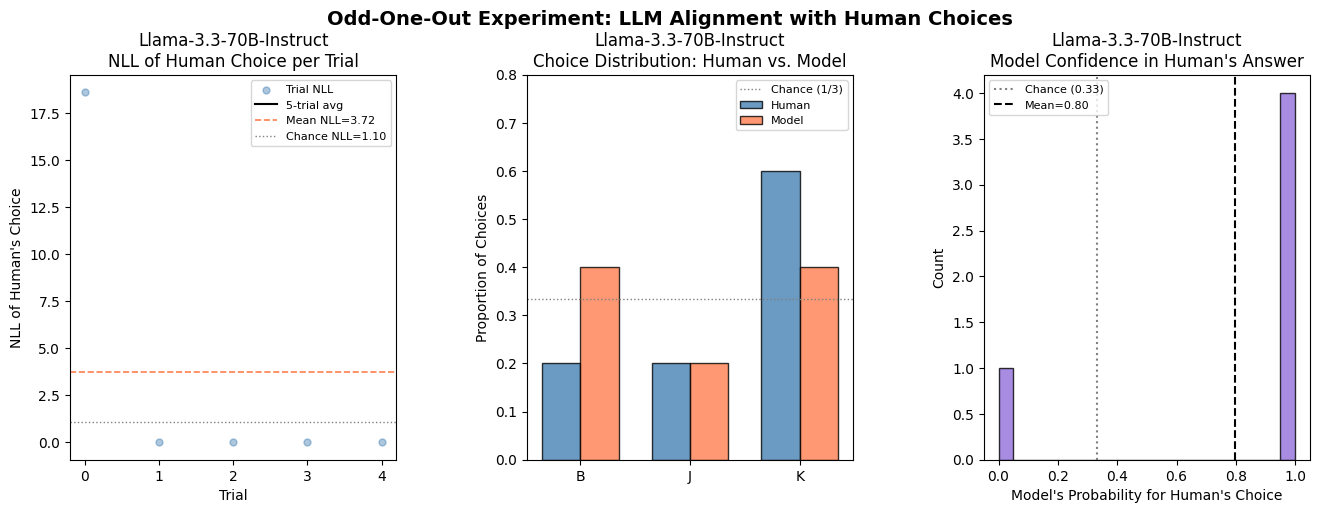

Figure saved to odd_one_out_results.png


In [25]:
n_models = len(all_results)
fig = plt.figure(figsize=(16, 5 * n_models))
gs  = gridspec.GridSpec(n_models, 3, hspace=0.55, wspace=0.4)

for row_idx, (model_id, results) in enumerate(all_results.items()):
    df   = pd.DataFrame(results)
    nlls = df["nll"].values.astype(float)

    # ── Panel 1: NLL per trial with rolling average ───────────────────────
    ax1 = fig.add_subplot(gs[row_idx, 0])
    ax1.scatter(df["trial_idx"], nlls, alpha=0.45, s=25, color="steelblue", label="Trial NLL", zorder=3)
    window = min(10, len(nlls))
    if window > 1:
        rolling = np.convolve(np.where(np.isnan(nlls), 0, nlls), np.ones(window)/window, mode="valid")
        ax1.plot(df["trial_idx"].values[window-1:], rolling, color="black",
                 linewidth=1.5, label=f"{window}-trial avg", zorder=4)
    chance_nll = math.log(3)
    ax1.axhline(np.nanmean(nlls), color="coral",  linestyle="--", linewidth=1.2,
                label=f"Mean NLL={np.nanmean(nlls):.2f}")
    ax1.axhline(chance_nll,       color="gray",   linestyle=":",  linewidth=1,
                label=f"Chance NLL={chance_nll:.2f}")
    ax1.set_xlabel("Trial")
    ax1.set_ylabel("NLL of Human's Choice")
    ax1.set_title(f"{model_id}\nNLL of Human Choice per Trial")
    ax1.legend(fontsize=8)

    # ── Panel 2: Choice distribution comparison ───────────────────────────
    ax2 = fig.add_subplot(gs[row_idx, 1])
    x = np.arange(len(VALID_KEYS))
    w = 0.35
    human_vals = [human_choice_dist.get(k, 0) for k in sorted(VALID_KEYS)]
    model_vals = [(df["model_choice"] == k).mean() for k in sorted(VALID_KEYS)]

    ax2.bar(x - w/2, human_vals, w, label="Human",       color="steelblue", alpha=0.8, edgecolor="black")
    ax2.bar(x + w/2, model_vals, w, label=f"Model",      color="coral",    alpha=0.8, edgecolor="black")
    ax2.axhline(1/3, color="gray", linestyle=":", linewidth=1, label="Chance (1/3)")
    ax2.set_xticks(x)
    ax2.set_xticklabels(sorted(VALID_KEYS))
    ax2.set_ylabel("Proportion of Choices")
    ax2.set_ylim(0, 0.8)
    ax2.set_title(f"{model_id}\nChoice Distribution: Human vs. Model")
    ax2.legend(fontsize=8)

    # ── Panel 3: Model probability assigned to correct (human) key ────────
    ax3 = fig.add_subplot(gs[row_idx, 2])
    # For each trial: what probability did the model give to the human's choice?
    human_probs = []
    for _, r in df.iterrows():
        p = r[f"prob_{r['human_choice']}"]
        human_probs.append(p)
    ax3.hist(human_probs, bins=20, color="mediumpurple", edgecolor="black", alpha=0.8)
    ax3.axvline(1/3, color="gray",  linestyle=":",  linewidth=1.5, label="Chance (0.33)")
    ax3.axvline(np.nanmean(human_probs), color="black", linestyle="--", linewidth=1.5,
                label=f"Mean={np.nanmean(human_probs):.2f}")
    ax3.set_xlabel("Model's Probability for Human's Choice")
    ax3.set_ylabel("Count")
    ax3.set_title(f"{model_id}\nModel Confidence in Human's Answer")
    ax3.legend(fontsize=8)

plt.suptitle("Odd-One-Out Experiment: LLM Alignment with Human Choices",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("odd_one_out_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to odd_one_out_results.png")

---
## 8. Save Results to CSV

Save all trial-level data for later analysis.

In [26]:
all_dfs = []
for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    df["model"] = model_id
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df.to_csv("odd_one_out_results.csv", index=False)
print(f"Saved {len(combined_df)} trial records to odd_one_out_results.csv")
combined_df.head()

Saved 5 trial records to odd_one_out_results.csv


,trial_idx,B,J,K,human_choice,model_choice,lp_B,lp_J,lp_K,prob_B,prob_J,prob_K,nll,correct,model
0,0,prune,nail polish,diskette,K,B,0.000000,-17.135418,-18.593750,1.000000e+00,3.615618e-08,8.410793e-09,18.593750,False,Llama-3.3-70B-Instruct
1,1,ladle,water bottle,pug,K,K,-20.364586,-38.489586,0.000000,1.431439e-09,1.923912e-17,1.000000e+00,-0.000000,True,Llama-3.3-70B-Instruct
2,2,punch,hair,lollipop,J,J,-5.576707,-0.003793,-14.326711,3.785010e-03,9.962144e-01,5.997754e-07,0.003793,True,Llama-3.3-70B-Instruct
3,3,oar,mug,macaroni,B,B,-0.003601,-5.628601,-14.066105,9.964056e-01,3.593599e-03,7.783381e-07,0.003601,True,Llama-3.3-70B-Instruct
4,4,towel,hot tub,mallet,K,K,-6.615926,-27.345089,-0.001340,1.338875e-03,1.331002e-12,9.986611e-01,0.001340,True,Llama-3.3-70B-Instruct


---
## 9. Inspect Disagreements

Look at the specific trials where model and human disagree most — useful for qualitative analysis.

In [27]:
for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    disagreements = df[df["correct"] == False].copy()
    disagreements = disagreements.sort_values("nll", ascending=False).head(10)

    print(f"\n=== Top disagreements for {model_id} ===")
    print(f"{'B':20s} {'J':20s} {'K':20s} {'Human':7s} {'Model':7s} {'NLL':6s}")
    print("-" * 80)
    for _, row in disagreements.iterrows():
        print(f"{row['B']:20s} {row['J']:20s} {row['K']:20s} "
              f"{row['human_choice']:7s} {row['model_choice']:7s} {row['nll']:.3f}")


=== Top disagreements for Llama-3.3-70B-Instruct ===
B                    J                    K                    Human   Model   NLL   
--------------------------------------------------------------------------------
prune                nail polish          diskette             K       B       18.594


---
## 10. Next Steps

Now that this text-only pipeline is working, you can extend it in several ways:

1. **More trials / more participants** — increase `N_TRIALS` and `MAX_PARTICIPANTS`
2. **More models** — add any model available on the Brown LiteLLM API to `MODELS_TO_TEST`
3. **Vision extension** — replace word labels with actual images of the objects (requires a VLM like GPT-5.2 and sourcing THINGS images)
4. **Participant-level analysis** — group by `participant_id` to ask whether alignment varies across individuals
5. **Triplet difficulty** — use human agreement rate per triplet as a proxy for difficulty; check whether model alignment is higher on "easy" (high-agreement) triplets
6. **Embedding comparison** — compare the model's choice distributions to cosine similarity from word embeddings (e.g., GloVe) as an additional baseline